In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Understanding data wrangling**

## **Data cleaning**

- **Renaming**
- **Sorting and reordering**
- **Data type conversions**
- **Handling duplicate data**
- **Addressing missing or invalid data**
- **Filtering to the desired subset of data**

## **Data transformation**

![wide format versus long format](../Images/wide_format_versus_long_format.png)

In [3]:
df_wide = pd.read_csv(
    '../Datasets/wide_data.csv',
    parse_dates=['date']
)

df_long = pd.read_csv(
    '../Datasets/long_data.csv',
    usecols=['date', 'datatype', 'value'],
    parse_dates=['date']
)[['date', 'datatype', 'value']] # Sort Column in assignment

### **The wide data format**

In [4]:
df_wide.head(6)

,date,TMAX,TMIN,TOBS
0,2018-10-01,21.1,8.9,13.9
1,2018-10-02,23.9,13.9,17.2
2,2018-10-03,25.0,15.6,16.1
3,2018-10-04,22.8,11.7,11.7
4,2018-10-05,23.3,11.7,18.9
5,2018-10-06,20.0,13.3,16.1


In [8]:
df_wide.describe()

,date,TMAX,TMIN,TOBS
count,31,31.000000,31.000000,31.000000
mean,2018-10-16 00:00:00,16.829032,7.561290,10.022581
min,2018-10-01 00:00:00,7.800000,-1.100000,-1.100000
25%,2018-10-08 12:00:00,12.750000,2.500000,5.550000
50%,2018-10-16 00:00:00,16.100000,6.700000,8.300000
75%,2018-10-23 12:00:00,21.950000,13.600000,16.100000
max,2018-10-31 00:00:00,26.700000,17.800000,21.700000
std,NaN,5.714962,6.513252,6.596550


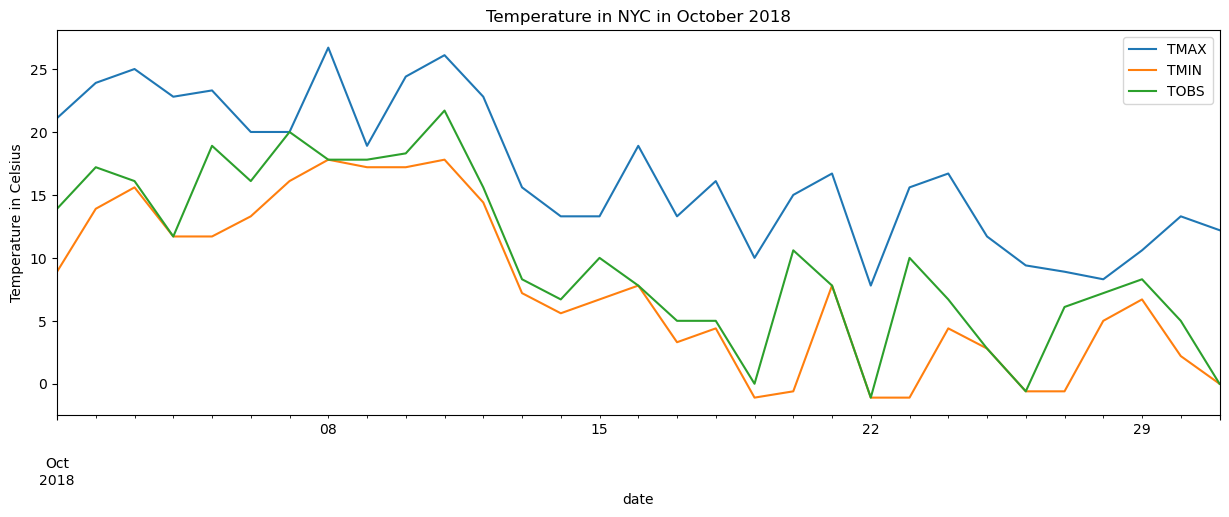

In [10]:
df_wide.plot(
    x = 'date',
    y = ['TMAX', 'TMIN', 'TOBS'],
    figsize=(15, 5),
    title = 'Temperature in NYC in October 2018'
).set_ylabel('Temperature in Celsius')
plt.show()

### **The long data format**

In [11]:
df_long.head(6)

,date,datatype,value
0,2018-10-01,TMAX,21.1
1,2018-10-01,TMIN,8.9
2,2018-10-01,TOBS,13.9
3,2018-10-02,TMAX,23.9
4,2018-10-02,TMIN,13.9
5,2018-10-02,TOBS,17.2


In [14]:
df_long.describe(include='all')

,date,datatype,value
count,93,93,93.000000
unique,NaN,3,NaN
top,NaN,TMAX,NaN
freq,NaN,31,NaN
mean,2018-10-16 00:00:00,NaN,11.470968
min,2018-10-01 00:00:00,NaN,-1.100000
25%,2018-10-08 00:00:00,NaN,6.700000
50%,2018-10-16 00:00:00,NaN,11.700000
75%,2018-10-24 00:00:00,NaN,17.200000
max,2018-10-31 00:00:00,NaN,26.700000


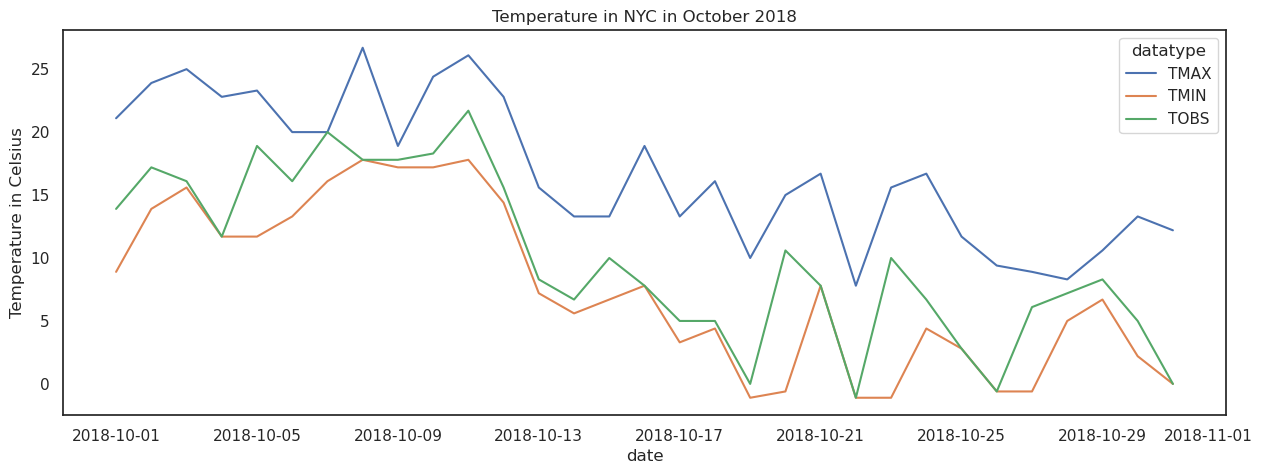

In [17]:
sns.set(rc={'figure.figsize': (15, 5)}, style='white')

ax = sns.lineplot(
    data=df_long,
    x='date',
    y='value',
    hue='datatype'
)
ax.set_ylabel('Temperature in Celsius')
ax.set_title('Temperature in NYC in October 2018')

plt.show()

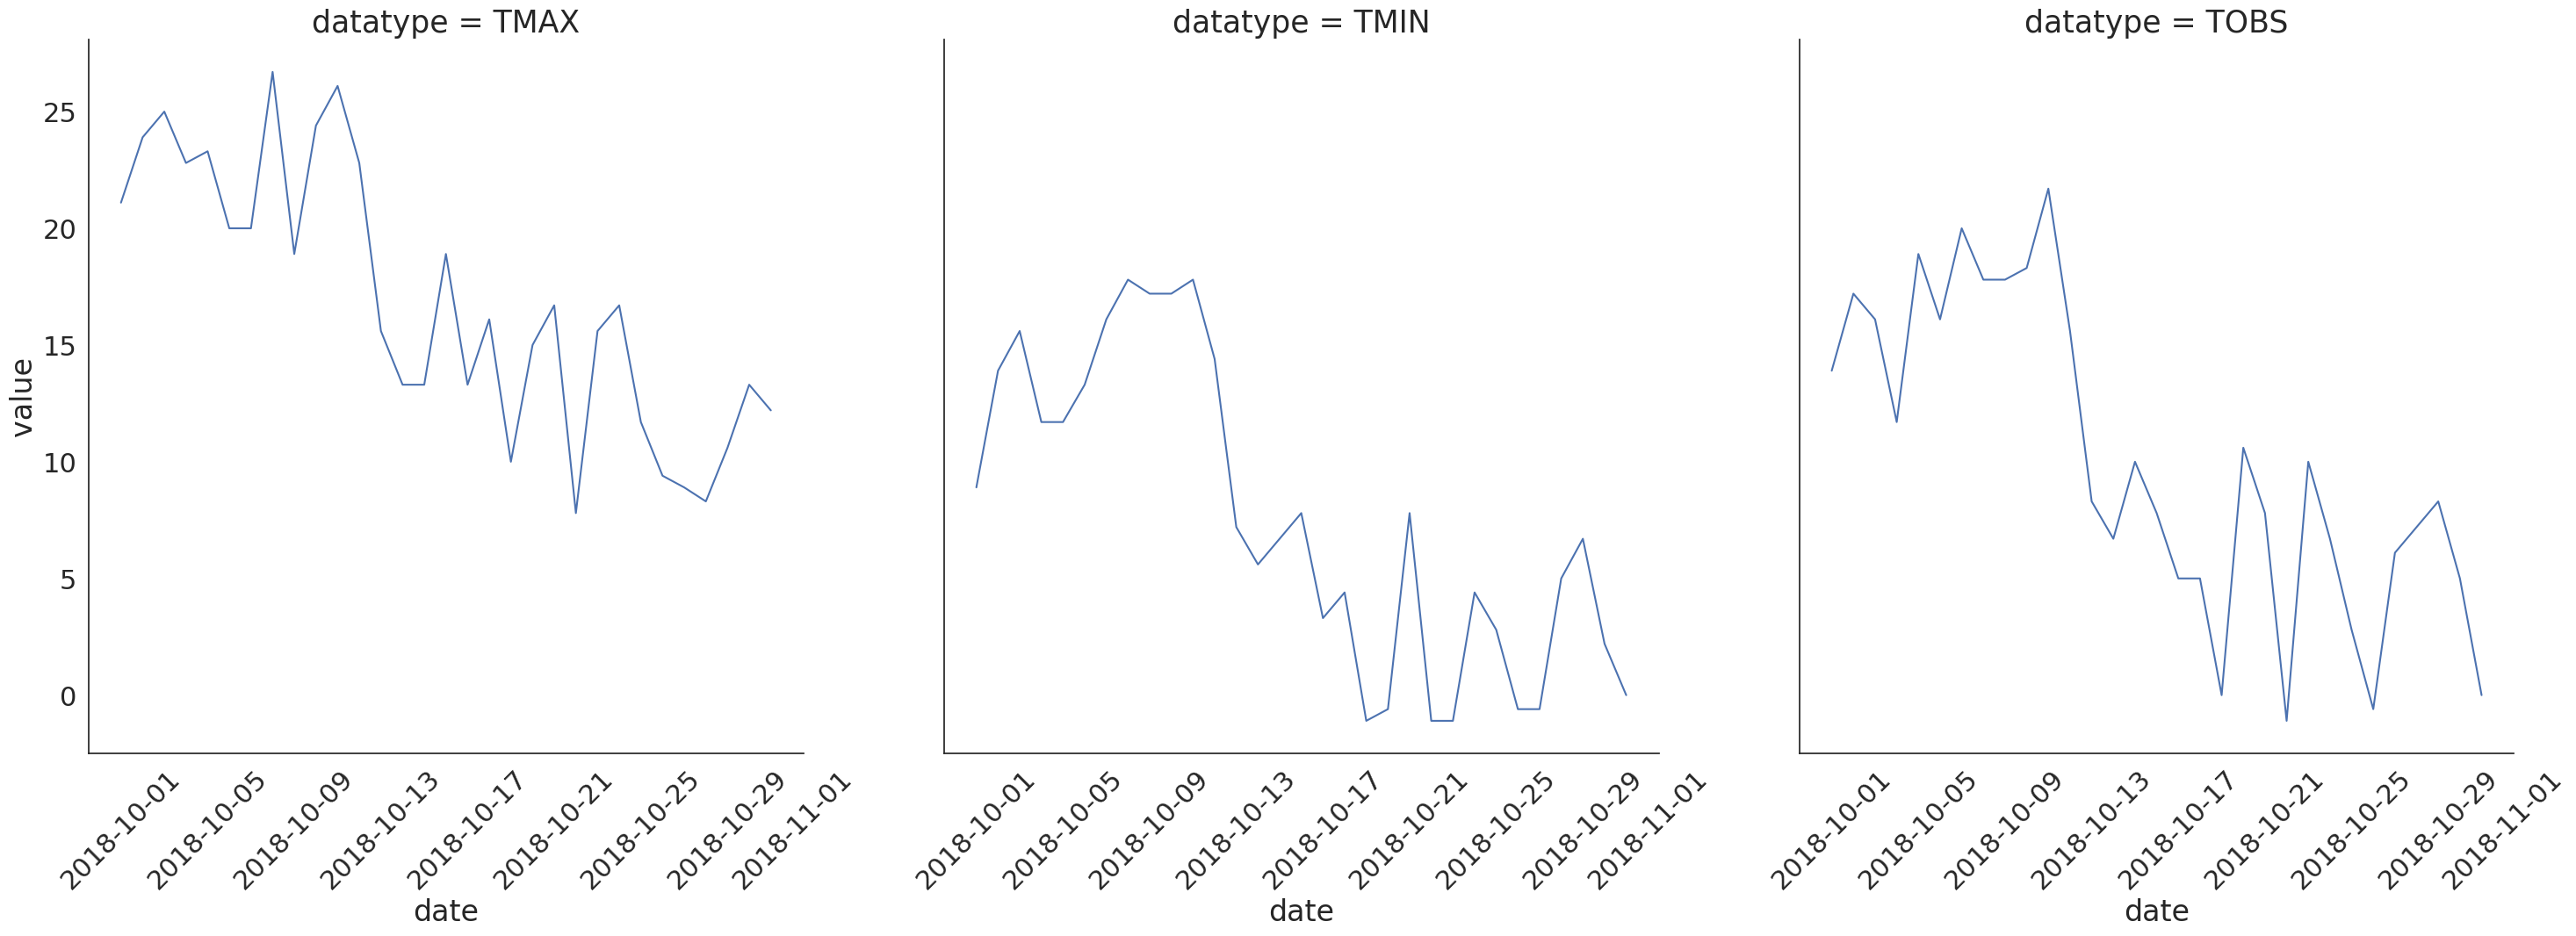

In [19]:
sns.set(
    rc={'figure.figsize': (20, 10)},
    style='white',
    font_scale=2
)

g = sns.FacetGrid(
    data=df_long,
    col='datatype',
    height=10
)

g = g.map(
    plt.plot,
    'date',
    'value'
)

g.set_titles(size=25)
g.set_xticklabels(rotation=45)
plt.show()

## **Data enrichment**

- **Adding new columns:** Using functions on the data from existing columns to create new values.
- **Binning:** Turning continuous data or discrete data with many distinct values into buckets, which makes the column discrete while letting us control the number of possible values in the column.
- **Aggregating:** Rolling up the data and summarizing it.
- **Resampling:** Aggregating time series data at specific intervals.

# **Exploring an API to find and collect temperature data**

In [2]:
import requests

In [1]:
import os
from dotenv import load_dotenv

In [2]:
# Load variables from .env file
load_dotenv()

# Access your key safely
token = os.getenv("MY_NCDC_KEY")

In [3]:
def make_request(endpoint, payload=None):
    """
    Make a request to a specific endpoint on the
    weather API passing headers and optional payload.
    Parameters:
        - endpoint: The endpoint of the API you want to
            make a GET request to.
        - payload: A dictionary of data to pass along
            with the request.
    Returns:
        A response object.
    """
    
    return requests.get(
        'https://www.ncdc.noaa.gov/cdo-web/'
        f'api/v2/{endpoint}',
        headers = {
            'token': token
        },
        params=payload
    )

In [5]:
response = make_request('datasets', {'startdate': '2018-10-01'})

In [6]:
response.status_code

200

In [7]:
response.ok

True

In [8]:
payload = response.json()

payload.keys()

dict_keys(['metadata', 'results'])

In [9]:
payload['metadata']

{'resultset': {'offset': 1, 'count': 11, 'limit': 25}}

In [12]:
payload['results'][0].keys()

dict_keys(['uid', 'mindate', 'maxdate', 'name', 'datacoverage', 'id'])

In [15]:
[(data['id'], data['name']) for data in payload['results']]

[('GHCND', 'Daily Summaries'),
 ('GSOM', 'Global Summary of the Month'),
 ('GSOY', 'Global Summary of the Year'),
 ('NEXRAD2', 'Weather Radar (Level II)'),
 ('NEXRAD3', 'Weather Radar (Level III)'),
 ('NORMAL_ANN', 'Normals Annual/Seasonal'),
 ('NORMAL_DLY', 'Normals Daily'),
 ('NORMAL_HLY', 'Normals Hourly'),
 ('NORMAL_MLY', 'Normals Monthly'),
 ('PRECIP_15', 'Precipitation 15 Minute'),
 ('PRECIP_HLY', 'Precipitation Hourly')]

In [16]:
response = make_request(
    'datacategories',
    payload={'datasetid': 'GHCND'}
)

In [17]:
response.status_code, response.ok

(200, True)

In [18]:
response.json()['results']

[{'name': 'Evaporation', 'id': 'EVAP'},
 {'name': 'Land', 'id': 'LAND'},
 {'name': 'Precipitation', 'id': 'PRCP'},
 {'name': 'Sky cover & clouds', 'id': 'SKY'},
 {'name': 'Sunshine', 'id': 'SUN'},
 {'name': 'Air Temperature', 'id': 'TEMP'},
 {'name': 'Water', 'id': 'WATER'},
 {'name': 'Wind', 'id': 'WIND'},
 {'name': 'Weather Type', 'id': 'WXTYPE'}]

In [20]:
response = make_request(
    'datatypes',
    payload={
        'datacategoryid': 'TEMP',
        'limit': 100
    }
)

In [21]:
response.ok

True

In [22]:
[(datatype['id'], datatype['name']) 
 for datatype in response.json()['results']]

[('CDSD', 'Cooling Degree Days Season to Date'),
 ('DATN',
  'Number of days included in the multiday minimum temperature (MDTN)'),
 ('DATX',
  'Number of days included in the multiday maximum temperature (MDTX)'),
 ('DLY-DUTR-NORMAL', 'Long-term averages of daily diurnal temperature range'),
 ('DLY-DUTR-STDDEV',
  'Long-term standard deviations of daily diurnal temperature range'),
 ('DLY-TAVG-NORMAL', 'Long-term averages of daily average temperature'),
 ('DLY-TAVG-STDDEV',
  'Long-term standard deviations of daily average temperature'),
 ('DLY-TMAX-NORMAL', 'Long-term averages of daily maximum temperature'),
 ('DLY-TMAX-STDDEV',
  'Long-term standard deviations of daily maximum temperature'),
 ('DLY-TMIN-NORMAL', 'Long-term averages of daily minimum temperature'),
 ('DLY-TMIN-STDDEV',
  'Long-term standard deviations of daily minimum temperature'),
 ('EMNT', 'Extreme minimum temperature for the period.'),
 ('EMXT', 'Extreme maximum temperature for the period.'),
 ('HDSD', 'Heating De

In [23]:
response = make_request(
    'locationcategories',
    payload={'datasetid': 'GHCND'}
)

response.ok

True

In [24]:
response.status_code

200

In [25]:
import pprint

In [26]:
pprint.pprint(response.json())

{'metadata': {'resultset': {'count': 12, 'limit': 25, 'offset': 1}},
 'results': [{'id': 'CITY', 'name': 'City'},
             {'id': 'CLIM_DIV', 'name': 'Climate Division'},
             {'id': 'CLIM_REG', 'name': 'Climate Region'},
             {'id': 'CNTRY', 'name': 'Country'},
             {'id': 'CNTY', 'name': 'County'},
             {'id': 'HYD_ACC', 'name': 'Hydrologic Accounting Unit'},
             {'id': 'HYD_CAT', 'name': 'Hydrologic Cataloging Unit'},
             {'id': 'HYD_REG', 'name': 'Hydrologic Region'},
             {'id': 'HYD_SUB', 'name': 'Hydrologic Subregion'},
             {'id': 'ST', 'name': 'State'},
             {'id': 'US_TERR', 'name': 'US Territory'},
             {'id': 'ZIP', 'name': 'Zip Code'}]}


In [36]:
def get_item(name, what, endpoint, start=1, end=None):
    """
    Grab the JSON payload using binary search.
    Parameters:
        - name: The item to look for.
        - what: Dictionary specifying what item `name` is.
        - endpoint: Where to look for the item.
        - start: The position to start at. We don't need
            to touch this, but the function will manipulate
            this with recursion.
        - end: The last position of the items. Used to
            find the midpoint, but like `start` this is not
            something we need to worry about.
    Returns: Dictionary of the information for the item
        if found, otherwise an empty dictionary.
"""
    # find the midpoint to cut the data in half each time
    mid = (start + (end or 1)) // 2

    # lowercase the name so this is not case-sensitive
    name = name.lower()

    # define the payload we will send with each request
    payload = {
        'datasetid': 'GHCND',
        'sortfield': 'name',
        'offset': mid, # we'll change the offset each time
        'limit': 1 # we only want one value back
    }

    # make request adding additional filters from `what`
    response = make_request(endpoint, {**payload, **what})

    if response.ok:
        payload = response.json()

        # if ok, grab the end index from the response
        # metadata the first time through
        end = end or payload['metadata']['resultset']['count']

        # grab the lowercase version of the current name
        current_name = payload['results'][0]['name'].lower()

        # if what we are searching for is in the current
        # name, we have found our item
        if name in current_name:
            # return the found item
            return payload['results'][0]
        else:
            if start >= end:
                # if start index is greater than or equal
                # to end index, we couldn't find it
                return {}
            elif name < current_name:
                # name comes before the current name in the
                # alphabet => search further to the left
                return get_item(name, what, endpoint, start, mid - 1)
            elif name > current_name:
                # name comes after the current name in the
                # alphabet => search further to the right
                return get_item(name, what, endpoint, mid + 1, end)
            else:
                # response wasn't ok, use code to determine why
                print('response not okay ', 
                      f'status : {response.status_code}')

In [37]:
nyc = get_item(
    'New York', {'locationcategoryid': 'CITY'}, 'locations'
)

nyc

{'mindate': '1843-05-01',
 'maxdate': '2026-07-20',
 'name': 'New York, NY US',
 'datacoverage': 1,
 'id': 'CITY:US360019'}

In [38]:
central_park = get_item(
    'NY City Central Park',
    {'locationid': nyc['id']},
    'stations'
)

central_park

{'elevation': 42.7,
 'mindate': '1869-01-01',
 'maxdate': '2026-07-19',
 'latitude': 40.77898,
 'name': 'NY CITY CENTRAL PARK, NY US',
 'datacoverage': 1,
 'id': 'GHCND:USW00094728',
 'elevationUnit': 'METERS',
 'longitude': -73.96925}

In [39]:
response = make_request(
    'data',
    {
        'datasetid': 'GHCND',
        'stationid': central_park['id'],
        'locationid': nyc['id'],
        'startdate': '2018-10-01',
        'enddate': '2018-10-31',
        'datatypeid': ['TAVG', 'TMAX', 'TMIN'],
        'units': 'metric',
        'limit': 1000
    }
)

In [40]:
response.status_code

200

In [47]:
df = pd.DataFrame(response.json()['results'])

df.head()

,date,datatype,station,attributes,value
0,2018-10-01T00:00:00,TMAX,GHCND:USW00094728,",,W,2400",24.4
1,2018-10-01T00:00:00,TMIN,GHCND:USW00094728,",,W,2400",17.2
2,2018-10-02T00:00:00,TMAX,GHCND:USW00094728,",,W,2400",25.0
3,2018-10-02T00:00:00,TMIN,GHCND:USW00094728,",,W,2400",18.3
4,2018-10-03T00:00:00,TMAX,GHCND:USW00094728,",,W,2400",23.3


In [48]:
df['datatype'].unique()

array(['TMAX', 'TMIN'], dtype=object)

In [50]:
if get_item(
    'NY City Central Park',
    {'locationid': nyc['id'], 'datatypeid': 'TAVG'},
    'stations'
): print("Found!!")

Found!!


# **Cleaning data**

In [51]:
df = pd.read_csv('../Datasets/nyc_temperatures.csv')

df.head()

,date,datatype,station,attributes,value
0,2018-10-01T00:00:00,TAVG,GHCND:USW00014732,"H,,S,",21.2
1,2018-10-01T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",25.6
2,2018-10-01T00:00:00,TMIN,GHCND:USW00014732,",,W,2400",18.3
3,2018-10-02T00:00:00,TAVG,GHCND:USW00014732,"H,,S,",22.7
4,2018-10-02T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",26.1


## **Renaming columns**

In [52]:
df.columns

Index(['date', 'datatype', 'station', 'attributes', 'value'], dtype='object')

In [58]:
df.rename(
    columns={
        'value': 'temp_C',
        'attributes': 'flags'
    },
    inplace=True
)

In [59]:
df.columns

Index(['date', 'datatype', 'station', 'flags', 'temp_C'], dtype='object')

> **Tip :** Both Series and Index objects can also be renamed using their **rename()** methods. Simply pass in the new name. For example, if we have a Series object called temperature and we want to rename it temp_C, we can run **temperature.rename('temp_C')**. The variable will still be called temperature, but the name of the data in the series itself will now be temp_C.

In [61]:
df.rename(
    str.upper,
    axis='columns'
).columns

Index(['DATE', 'DATATYPE', 'STATION', 'FLAGS', 'TEMP_C'], dtype='object')

## **Type conversion**

In [62]:
df.dtypes

date         object
datatype     object
station      object
flags        object
temp_C      float64
dtype: object

In [74]:
df['date'] = pd.to_datetime(df.date)

df.dtypes

date        datetime64[ns]
datatype            object
station             object
flags               object
temp_C             float64
dtype: object

In [75]:
df.date.describe()

count                     93
mean     2018-10-16 00:00:00
min      2018-10-01 00:00:00
25%      2018-10-08 00:00:00
50%      2018-10-16 00:00:00
75%      2018-10-24 00:00:00
max      2018-10-31 00:00:00
Name: date, dtype: object

In [76]:
pd.date_range(start="2019-06-25", periods=2, freq="D").tz_localize('EST')

DatetimeIndex(['2019-06-25 00:00:00-05:00', '2019-06-26 00:00:00-05:00'], dtype='datetime64[ns, EST]', freq=None)

In [77]:
eastern = pd.read_csv(
    '../Datasets/nyc_temperatures.csv',
    index_col='date',
    parse_dates=True
).tz_localize('EST')

eastern.head()

,datatype,station,attributes,value
date,,,,
2018-10-01 00:00:00-05:00,TAVG,GHCND:USW00014732,"H,,S,",21.2
2018-10-01 00:00:00-05:00,TMAX,GHCND:USW00014732,",,W,2400",25.6
2018-10-01 00:00:00-05:00,TMIN,GHCND:USW00014732,",,W,2400",18.3
2018-10-02 00:00:00-05:00,TAVG,GHCND:USW00014732,"H,,S,",22.7
2018-10-02 00:00:00-05:00,TMAX,GHCND:USW00014732,",,W,2400",26.1


In [78]:
eastern.tz_convert('UTC').head()

,datatype,station,attributes,value
date,,,,
2018-10-01 05:00:00+00:00,TAVG,GHCND:USW00014732,"H,,S,",21.2
2018-10-01 05:00:00+00:00,TMAX,GHCND:USW00014732,",,W,2400",25.6
2018-10-01 05:00:00+00:00,TMIN,GHCND:USW00014732,",,W,2400",18.3
2018-10-02 05:00:00+00:00,TAVG,GHCND:USW00014732,"H,,S,",22.7
2018-10-02 05:00:00+00:00,TMAX,GHCND:USW00014732,",,W,2400",26.1


In [81]:
eastern.tz_localize(None).to_period('M').index

PeriodIndex(['2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-10', '2018-10', '2018-10',
             '2018-10', '2018-10', '2018-10', '2018-

In [82]:
eastern.tz_localize(None).to_period('M').to_timestamp().index

DatetimeIndex(['2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
               '2018-10-01', '2018-10-01', '2018-10-01', '2018-10-01',
      

In [83]:
df = pd.read_csv(
    '../Datasets/nyc_temperatures.csv',
).rename(
    columns={'value': 'temp_C', 'attributes': 'flags'}
)

df.head()

,date,datatype,station,flags,temp_C
0,2018-10-01T00:00:00,TAVG,GHCND:USW00014732,"H,,S,",21.2
1,2018-10-01T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",25.6
2,2018-10-01T00:00:00,TMIN,GHCND:USW00014732,",,W,2400",18.3
3,2018-10-02T00:00:00,TAVG,GHCND:USW00014732,"H,,S,",22.7
4,2018-10-02T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",26.1


In [87]:
new_df = df.assign(
    date = pd.to_datetime(df['date']),
    temp_F = (df.temp_C * 9/5) + 32
)

In [88]:
new_df.dtypes

date        datetime64[ns]
datatype            object
station             object
flags               object
temp_C             float64
temp_F             float64
dtype: object

In [89]:
new_df.head()

,date,datatype,station,flags,temp_C,temp_F
0,2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,70.16
1,2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,78.08
2,2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,64.94
3,2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,72.86
4,2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,78.98


In [93]:
df = df.assign(
    date = lambda x: pd.to_datetime(x.date),
    temp_C_whole = lambda x: x.temp_C.astype(np.int8),
    temp_F = lambda x: (x.temp_C * 9/5) + 32,
    temp_F_whole = lambda x: x.temp_F.astype(np.int16)
)

df.head()

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
0,2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
1,2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
2,2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,18,64.94,64
3,2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
4,2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78


In [95]:
df_with_categories = df.assign(
    station = df.station.astype('category'),
    datatype = df.datatype.astype('category')
)

df_with_categories.dtypes

date            datetime64[ns]
datatype              category
station               category
flags                   object
temp_C                 float64
temp_C_whole              int8
temp_F                 float64
temp_F_whole             int16
dtype: object

In [97]:
df_with_categories.describe(include=['category'])

,datatype,station
count,93,93
unique,3,1
top,TAVG,GHCND:USW00014732
freq,31,93


In [98]:
pd.Categorical(
    ['med', 'med', 'low', 'high'],
    categories=['low', 'med', 'high'],
    ordered=True
)

['med', 'med', 'low', 'high']
Categories (3, object): ['low' < 'med' < 'high']

## **Reordering, reindexing, and sorting data**

In [101]:
df.loc[df['datatype'] == 'TMAX'].sort_values(by='temp_C', ascending=False).head(10)

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
19,2018-10-07,TMAX,GHCND:USW00014732,",,W,2400",27.8,27,82.04,82
28,2018-10-10,TMAX,GHCND:USW00014732,",,W,2400",27.8,27,82.04,82
31,2018-10-11,TMAX,GHCND:USW00014732,",,W,2400",26.7,26,80.06,80
10,2018-10-04,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
4,2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
1,2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
25,2018-10-09,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
7,2018-10-03,TMAX,GHCND:USW00014732,",,W,2400",25.0,25,77.00,77
13,2018-10-05,TMAX,GHCND:USW00014732,",,W,2400",22.8,22,73.04,73
22,2018-10-08,TMAX,GHCND:USW00014732,",,W,2400",22.8,22,73.04,73


In [104]:
df[df['datatype'] == 'TMAX'].sort_values(by=['temp_C', 'date'], ascending=[False, True]).head(10)

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
19,2018-10-07,TMAX,GHCND:USW00014732,",,W,2400",27.8,27,82.04,82
28,2018-10-10,TMAX,GHCND:USW00014732,",,W,2400",27.8,27,82.04,82
31,2018-10-11,TMAX,GHCND:USW00014732,",,W,2400",26.7,26,80.06,80
4,2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
10,2018-10-04,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
1,2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
25,2018-10-09,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
7,2018-10-03,TMAX,GHCND:USW00014732,",,W,2400",25.0,25,77.00,77
13,2018-10-05,TMAX,GHCND:USW00014732,",,W,2400",22.8,22,73.04,73
22,2018-10-08,TMAX,GHCND:USW00014732,",,W,2400",22.8,22,73.04,73


> **Tip :** In pandas, the index is tied to the rows—when we drop rows, filter, or do anything that returns only some of the rows, our index may look out of order (as we saw in the previous examples). At the moment, the index just represents the row number in our data, so we may be interested in changing the values so that we have the first entry at index 0. To have pandas do so automatically, we can pass **ignore_index=True** to **sort_values()**.

In [105]:
df[df['datatype'] == 'TAVG'].nlargest(n=10, columns='temp_C')

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
27,2018-10-10,TAVG,GHCND:USW00014732,"H,,S,",23.8,23,74.84,74
30,2018-10-11,TAVG,GHCND:USW00014732,"H,,S,",23.4,23,74.12,74
18,2018-10-07,TAVG,GHCND:USW00014732,"H,,S,",22.8,22,73.04,73
3,2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
6,2018-10-03,TAVG,GHCND:USW00014732,"H,,S,",21.8,21,71.24,71
24,2018-10-09,TAVG,GHCND:USW00014732,"H,,S,",21.8,21,71.24,71
9,2018-10-04,TAVG,GHCND:USW00014732,"H,,S,",21.3,21,70.34,70
0,2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
21,2018-10-08,TAVG,GHCND:USW00014732,"H,,S,",20.9,20,69.62,69
12,2018-10-05,TAVG,GHCND:USW00014732,"H,,S,",20.3,20,68.54,68


In [106]:
df.sample(n=5, random_state=0).index

Index([2, 30, 55, 16, 13], dtype='int64')

In [107]:
df.sample(
    n=5,
    random_state=0
).sort_index().index

Index([2, 13, 16, 30, 55], dtype='int64')

> **Tip :** If we need the result of **sample()** to be reproducible, we can pass in a seed, set to a number of our choosing (using the random_state argument). The seed initializes a pseudorandom number generator, so, provided that the same seed is used, the results will be the same.

In [108]:
df.sort_index().head(2)

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
0,2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
1,2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78


In [109]:
df.sort_index(axis=1).head(2)

,datatype,date,flags,station,temp_C,temp_C_whole,temp_F,temp_F_whole
0,TAVG,2018-10-01,"H,,S,",GHCND:USW00014732,21.2,21,70.16,70
1,TMAX,2018-10-01,",,W,2400",GHCND:USW00014732,25.6,25,78.08,78


> **Important note :** Both **sort_index()** and **sort_values()** return new DataFrame objects. We must pass in inplace=True to update the dataframe we are working with.

In [110]:
df.equals(
    df.sort_values(by='temp_C')
)

False

In [117]:
df.equals(df.sort_values(by='temp_C').sort_index())

True

In [119]:
df.set_index('date', inplace=True)

df.head()

,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
date,,,,,,,
2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,18,64.94,64
2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78


> **Tip :** We can also provide a list of columns to use as the index. This will create a **MultiIndex object**, where the first element in the list is the outermost level and the last is the innermost. We will discuss this further in the Pivoting DataFrames section.

In [121]:
df.loc['2018']

,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
date,,,,,,,
2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,18,64.94,64
2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
...,...,...,...,...,...,...,...
2018-10-30,TMAX,GHCND:USW00014732,",,W,2400",13.9,13,57.02,57
2018-10-30,TMIN,GHCND:USW00014732,",,W,2400",7.2,7,44.96,44
2018-10-31,TAVG,GHCND:USW00014732,"H,,S,",12.6,12,54.68,54


In [122]:
df.loc['2018-Q4']

,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
date,,,,,,,
2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,18,64.94,64
2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
...,...,...,...,...,...,...,...
2018-10-30,TMAX,GHCND:USW00014732,",,W,2400",13.9,13,57.02,57
2018-10-30,TMIN,GHCND:USW00014732,",,W,2400",7.2,7,44.96,44
2018-10-31,TAVG,GHCND:USW00014732,"H,,S,",12.6,12,54.68,54


In [123]:
df.loc['2018-10']

,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
date,,,,,,,
2018-10-01,TAVG,GHCND:USW00014732,"H,,S,",21.2,21,70.16,70
2018-10-01,TMAX,GHCND:USW00014732,",,W,2400",25.6,25,78.08,78
2018-10-01,TMIN,GHCND:USW00014732,",,W,2400",18.3,18,64.94,64
2018-10-02,TAVG,GHCND:USW00014732,"H,,S,",22.7,22,72.86,72
2018-10-02,TMAX,GHCND:USW00014732,",,W,2400",26.1,26,78.98,78
...,...,...,...,...,...,...,...
2018-10-30,TMAX,GHCND:USW00014732,",,W,2400",13.9,13,57.02,57
2018-10-30,TMIN,GHCND:USW00014732,",,W,2400",7.2,7,44.96,44
2018-10-31,TAVG,GHCND:USW00014732,"H,,S,",12.6,12,54.68,54


In [124]:
df['2018-10-11':'2018-10-12']

,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
date,,,,,,,
2018-10-11,TAVG,GHCND:USW00014732,"H,,S,",23.4,23,74.12,74
2018-10-11,TMAX,GHCND:USW00014732,",,W,2400",26.7,26,80.06,80
2018-10-11,TMIN,GHCND:USW00014732,",,W,2400",21.7,21,71.06,71
2018-10-12,TAVG,GHCND:USW00014732,"H,,S,",18.3,18,64.94,64
2018-10-12,TMAX,GHCND:USW00014732,",,W,2400",22.2,22,71.96,71
2018-10-12,TMIN,GHCND:USW00014732,",,W,2400",12.2,12,53.96,53


In [125]:
df['2018-10-11':'2018-10-12'].reset_index()

,date,datatype,station,flags,temp_C,temp_C_whole,temp_F,temp_F_whole
0,2018-10-11,TAVG,GHCND:USW00014732,"H,,S,",23.4,23,74.12,74
1,2018-10-11,TMAX,GHCND:USW00014732,",,W,2400",26.7,26,80.06,80
2,2018-10-11,TMIN,GHCND:USW00014732,",,W,2400",21.7,21,71.06,71
3,2018-10-12,TAVG,GHCND:USW00014732,"H,,S,",18.3,18,64.94,64
4,2018-10-12,TMAX,GHCND:USW00014732,",,W,2400",22.2,22,71.96,71
5,2018-10-12,TMIN,GHCND:USW00014732,",,W,2400",12.2,12,53.96,53


In [2]:
sp = pd.read_csv(
    '../Datasets/sp500.csv',
    index_col='date',
    parse_dates=True
).drop(
    columns=['adj_close']
)

sp.head()

,high,low,open,close,volume
date,,,,,
2017-01-03,2263.879883,2245.129883,2251.570068,2257.830078,3770530000
2017-01-04,2272.820068,2261.600098,2261.600098,2270.750000,3764890000
2017-01-05,2271.500000,2260.449951,2268.179932,2269.000000,3761820000
2017-01-06,2282.100098,2264.060059,2271.139893,2276.979980,3339890000
2017-01-09,2275.489990,2268.899902,2273.590088,2268.899902,3217610000


In [3]:
sp.head(10).assign(
    day_of_week = lambda x: x.index.day_name()
)

,high,low,open,close,volume,day_of_week
date,,,,,,
2017-01-03,2263.879883,2245.129883,2251.570068,2257.830078,3770530000,Tuesday
2017-01-04,2272.820068,2261.600098,2261.600098,2270.750000,3764890000,Wednesday
2017-01-05,2271.500000,2260.449951,2268.179932,2269.000000,3761820000,Thursday
2017-01-06,2282.100098,2264.060059,2271.139893,2276.979980,3339890000,Friday
2017-01-09,2275.489990,2268.899902,2273.590088,2268.899902,3217610000,Monday
2017-01-10,2279.270020,2265.270020,2269.719971,2268.899902,3638790000,Tuesday
2017-01-11,2275.320068,2260.830078,2268.600098,2275.320068,3620410000,Wednesday
2017-01-12,2271.780029,2254.250000,2271.139893,2270.439941,3462130000,Thursday
2017-01-13,2278.679932,2271.510010,2272.739990,2274.639893,3081270000,Friday


> **Tip :** We can also do this with a series, but first, we need to access the dt attribute. For example, if we had a date column in the sp dataframe, we could grab the month with **sp.date.dt.month**.

In [4]:
bitcoin = pd.read_csv(
    '../Datasets/bitcoin.csv',
    index_col='date',
    parse_dates=True
).drop(columns=['market_cap'])

bitcoin.head()

,open,high,low,close,volume
date,,,,,
2017-01-01,963.66,1003.08,958.70,998.33,147775008
2017-01-02,998.62,1031.39,996.70,1021.75,222184992
2017-01-03,1021.60,1044.08,1021.60,1043.84,185168000
2017-01-04,1044.40,1159.42,1044.40,1154.73,344945984
2017-01-05,1156.73,1191.10,910.42,1013.38,510199008


In [5]:
sp.shape, bitcoin.shape

((502, 5), (730, 5))

In [6]:
# every day's closing price = S&P 500 close + Bitcoin close (same for other metrics)
portfolio = pd.concat(
    [sp, bitcoin], 
    sort=False
).groupby(level='date').sum()

portfolio.head(10).assign(
    day_of_week = lambda x: x.index.day_name()
)

,high,low,open,close,volume,day_of_week
date,,,,,,
2017-01-01,1003.080000,958.700000,963.660000,998.330000,147775008,Sunday
2017-01-02,1031.390000,996.700000,998.620000,1021.750000,222184992,Monday
2017-01-03,3307.959883,3266.729883,3273.170068,3301.670078,3955698000,Tuesday
2017-01-04,3432.240068,3306.000098,3306.000098,3425.480000,4109835984,Wednesday
2017-01-05,3462.600000,3170.869951,3424.909932,3282.380000,4272019008,Thursday
2017-01-06,3328.910098,3148.000059,3285.379893,3179.179980,3691766000,Friday
2017-01-07,908.590000,823.560000,903.490000,908.590000,279550016,Saturday
2017-01-08,942.720000,887.250000,908.170000,911.200000,158715008,Sunday
2017-01-09,3189.179990,3148.709902,3186.830088,3171.729902,3359486992,Monday


In [7]:
from matplotlib.ticker import StrMethodFormatter

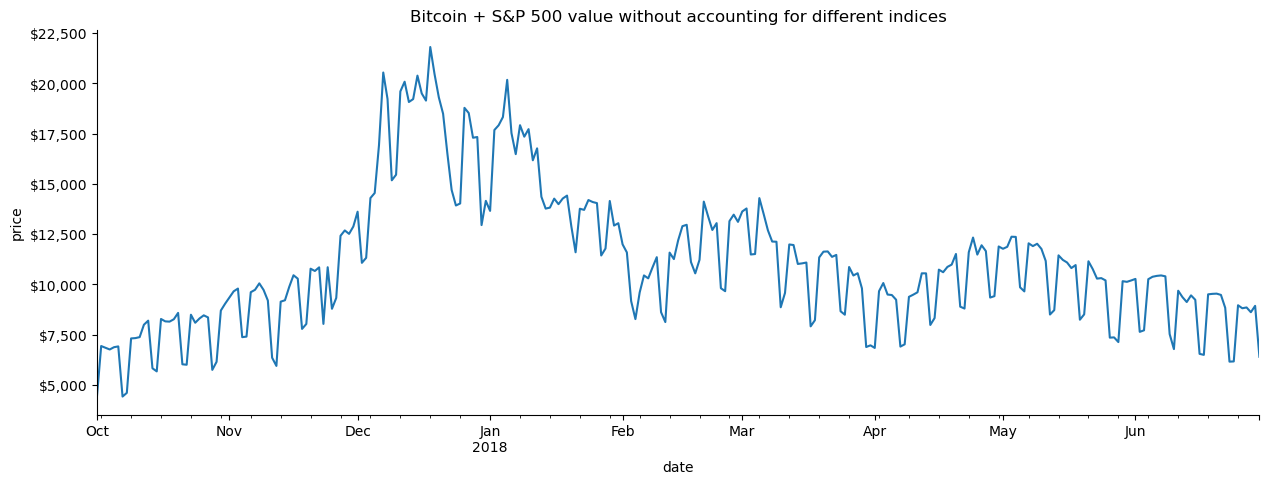

In [8]:
# plot the closing price from Q4 2017 through Q2 2018
ax = portfolio['2017-Q4':'2018-Q2'].plot(
    y='close',
    figsize=(15, 5),
    legend=False,
    title = 'Bitcoin + S&P 500 value without accounting for different indices'
)

# formatting
ax.set_ylabel('price')
ax.yaxis.set_major_formatter(
    StrMethodFormatter('${x:,.0f}')
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

In [16]:
sp.reindex(bitcoin.index, method='ffill') \
    .head(10) \
    .assign( day_of_week = lambda x: x.index.day_name())

,high,low,open,close,volume,day_of_week
date,,,,,,
2017-01-01,NaN,NaN,NaN,NaN,NaN,Sunday
2017-01-02,NaN,NaN,NaN,NaN,NaN,Monday
2017-01-03,2263.879883,2245.129883,2251.570068,2257.830078,3.770530e+09,Tuesday
2017-01-04,2272.820068,2261.600098,2261.600098,2270.750000,3.764890e+09,Wednesday
2017-01-05,2271.500000,2260.449951,2268.179932,2269.000000,3.761820e+09,Thursday
2017-01-06,2282.100098,2264.060059,2271.139893,2276.979980,3.339890e+09,Friday
2017-01-07,2282.100098,2264.060059,2271.139893,2276.979980,3.339890e+09,Saturday
2017-01-08,2282.100098,2264.060059,2271.139893,2276.979980,3.339890e+09,Sunday
2017-01-09,2275.489990,2268.899902,2273.590088,2268.899902,3.217610e+09,Monday


> **Tip :** The **`compare()`** method will show us the values that differ across identically-labeled dataframes (same index and columns); we can use it to isolate the changes in our data when forward-filling here.

In [19]:
sp_reindexed = sp.reindex(
    bitcoin.index).assign(
    # volume is 0 when the market is closed
    volume = lambda x: x.volume.fillna(0),
    # carry this forward
    close = lambda x: x.close.ffill(),
    # take the closing price if these aren't available
    open = lambda x: np.where(x.open.isnull(), x.close, x.open),
    high = lambda x: np.where(x.high.isnull(), x.close, x.open),
    low = lambda x: np.where(x.low.isnull(), x.close, x.open)
    )

sp_reindexed.head(10).assign(
    day_of_week = lambda x: x.index.day_name()
)

,high,low,open,close,volume,day_of_week
date,,,,,,
2017-01-01,NaN,NaN,NaN,NaN,0.000000e+00,Sunday
2017-01-02,NaN,NaN,NaN,NaN,0.000000e+00,Monday
2017-01-03,2251.570068,2251.570068,2251.570068,2257.830078,3.770530e+09,Tuesday
2017-01-04,2261.600098,2261.600098,2261.600098,2270.750000,3.764890e+09,Wednesday
2017-01-05,2268.179932,2268.179932,2268.179932,2269.000000,3.761820e+09,Thursday
2017-01-06,2271.139893,2271.139893,2271.139893,2276.979980,3.339890e+09,Friday
2017-01-07,2276.979980,2276.979980,2276.979980,2276.979980,0.000000e+00,Saturday
2017-01-08,2276.979980,2276.979980,2276.979980,2276.979980,0.000000e+00,Sunday
2017-01-09,2273.590088,2273.590088,2273.590088,2268.899902,3.217610e+09,Monday


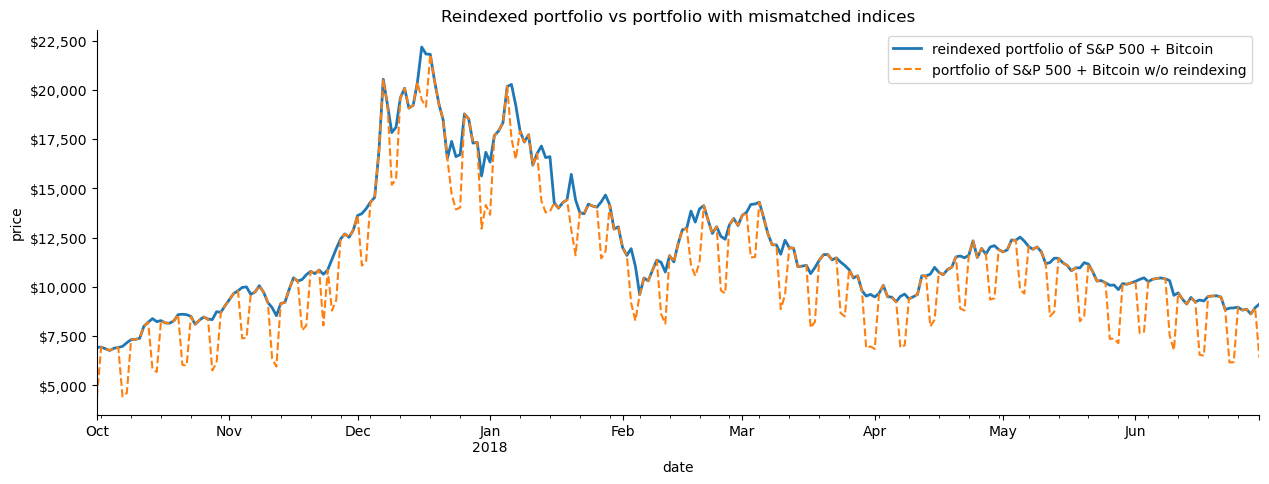

In [31]:
# every day's closing price = S&P 500 close adjusted for market closure + Bitcoin close (same for other metrics)
fixed_portfolio = sp_reindexed + bitcoin

# plot the reindexed portfolio's close (Q4 2017 - Q2 2018)
ax = fixed_portfolio['2017-Q4':'2018-Q2'].plot(
    y='close',
    figsize=(15, 5),
    linewidth=2,
    label='reindexed portfolio of S&P 500 + Bitcoin',
    title='Reindexed portfolio vs portfolio with mismatched indices'
)

# add line for original portfolio for comparison
portfolio['2017-Q4':'2018-Q2'].plot(
    y='close',
    ax=ax, 
    linestyle='--',
    label='portfolio of S&P 500 + Bitcoin w/o reindexing'
)

# formatting
ax.set_ylabel('price')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

> **Tip :** We can also use the **`reindex()`** method to reorder the rows. For example, if our data is stored in x, then x.reindex([32, 20, 11]) will return a new DataFrame object of three rows: 32, 20, and 11 (in that order). This can be done along the columns with **axis=1 (the default is axis=0 for rows)**.

# **Reshaping data**

In [34]:
long_df = pd.read_csv(
    '../Datasets/long_data.csv',
    usecols=['date', 'datatype', 'value']
).rename(
    columns={
        'value': 'temp_C'
    }
).assign(
    date = lambda x: pd.to_datetime(x.date),
    temp_F = lambda x: (x.temp_C * 9/5) + 32
)

long_df.head()

,datatype,date,temp_C,temp_F
0,TMAX,2018-10-01,21.1,69.98
1,TMIN,2018-10-01,8.9,48.02
2,TOBS,2018-10-01,13.9,57.02
3,TMAX,2018-10-02,23.9,75.02
4,TMIN,2018-10-02,13.9,57.02


## **Transposing DataFrames**

In [36]:
long_df.set_index('date').head(6).T

date,2018-10-01,2018-10-01,2018-10-01,2018-10-02,2018-10-02,2018-10-02
datatype,TMAX,TMIN,TOBS,TMAX,TMIN,TOBS
temp_C,21.1,8.9,13.9,23.9,13.9,17.2
temp_F,69.98,48.02,57.02,75.02,57.02,62.96


## **Pivoting DataFrames**

In [40]:
pivot_df = long_df.pivot(
    index='date',
    columns='datatype',
    values='temp_C'
)

pivot_df.head()

datatype,TMAX,TMIN,TOBS
date,,,
2018-10-01,21.1,8.9,13.9
2018-10-02,23.9,13.9,17.2
2018-10-03,25.0,15.6,16.1
2018-10-04,22.8,11.7,11.7
2018-10-05,23.3,11.7,18.9


In [41]:
pivot_df.describe()

datatype,TMAX,TMIN,TOBS
count,31.000000,31.000000,31.000000
mean,16.829032,7.561290,10.022581
std,5.714962,6.513252,6.596550
min,7.800000,-1.100000,-1.100000
25%,12.750000,2.500000,5.550000
50%,16.100000,6.700000,8.300000
75%,21.950000,13.600000,16.100000
max,26.700000,17.800000,21.700000


In [43]:
pivot_df = long_df.pivot(
    index='date',
    columns='datatype',
    values=['temp_C', 'temp_F']
)

pivot_df.head()

temp_C             temp_F              
datatype     TMAX  TMIN  TOBS   TMAX   TMIN   TOBS
date                                              
2018-10-01   21.1   8.9  13.9  69.98  48.02  57.02
2018-10-02   23.9  13.9  17.2  75.02  57.02  62.96
2018-10-03   25.0  15.6  16.1  77.00  60.08  60.98
2018-10-04   22.8  11.7  11.7  73.04  53.06  53.06
2018-10-05   23.3  11.7  18.9  73.94  53.06  66.02

In [44]:
pivot_df['temp_F']['TMIN'].head()

date
2018-10-01    48.02
2018-10-02    57.02
2018-10-03    60.08
2018-10-04    53.06
2018-10-05    53.06
Name: TMIN, dtype: float64

In [47]:
multi_index_df = long_df.set_index(['date', 'datatype'])

multi_index_df.head().index

MultiIndex([('2018-10-01', 'TMAX'),
            ('2018-10-01', 'TMIN'),
            ('2018-10-01', 'TOBS'),
            ('2018-10-02', 'TMAX'),
            ('2018-10-02', 'TMIN')],
           names=['date', 'datatype'])

In [48]:
multi_index_df.head()

temp_C  temp_F
date       datatype                
2018-10-01 TMAX        21.1   69.98
           TMIN         8.9   48.02
           TOBS        13.9   57.02
2018-10-02 TMAX        23.9   75.02
           TMIN        13.9   57.02

In [59]:
multi_index_df['2018-10-1': '2018-10-5']

temp_C  temp_F
date       datatype                
2018-10-01 TMAX        21.1   69.98
           TMIN         8.9   48.02
           TOBS        13.9   57.02
2018-10-02 TMAX        23.9   75.02
           TMIN        13.9   57.02
           TOBS        17.2   62.96
2018-10-03 TMAX        25.0   77.00
           TMIN        15.6   60.08
           TOBS        16.1   60.98
2018-10-04 TMAX        22.8   73.04
           TMIN        11.7   53.06
           TOBS        11.7   53.06
2018-10-05 TMAX        23.3   73.94
           TMIN        11.7   53.06
           TOBS        18.9   66.02

In [60]:
unstacked_df = multi_index_df.unstack()

unstacked_df.head()

temp_C             temp_F              
datatype     TMAX  TMIN  TOBS   TMAX   TMIN   TOBS
date                                              
2018-10-01   21.1   8.9  13.9  69.98  48.02  57.02
2018-10-02   23.9  13.9  17.2  75.02  57.02  62.96
2018-10-03   25.0  15.6  16.1  77.00  60.08  60.98
2018-10-04   22.8  11.7  11.7  73.04  53.06  53.06
2018-10-05   23.3  11.7  18.9  73.94  53.06  66.02

In [80]:
extra_data = pd.concat([
    pd.DataFrame([{
    'datatype': 'TAVG',
    'date': pd.to_datetime('2018-10-01'),
    'temp_C': 10,
    'temp_F': 50
}]),
    long_df
]).reset_index(drop=True).set_index(['date', 'datatype']).sort_index()

extra_data['2018-10-01':'2018-10-02']

temp_C  temp_F
date       datatype                
2018-10-01 TAVG        10.0   50.00
           TMAX        21.1   69.98
           TMIN         8.9   48.02
           TOBS        13.9   57.02
2018-10-02 TMAX        23.9   75.02
           TMIN        13.9   57.02
           TOBS        17.2   62.96

In [81]:
extra_data.unstack().head()

temp_C                   temp_F                     
datatype     TAVG  TMAX  TMIN  TOBS   TAVG   TMAX   TMIN   TOBS
date                                                           
2018-10-01   10.0  21.1   8.9  13.9   50.0  69.98  48.02  57.02
2018-10-02    NaN  23.9  13.9  17.2    NaN  75.02  57.02  62.96
2018-10-03    NaN  25.0  15.6  16.1    NaN  77.00  60.08  60.98
2018-10-04    NaN  22.8  11.7  11.7    NaN  73.04  53.06  53.06
2018-10-05    NaN  23.3  11.7  18.9    NaN  73.94  53.06  66.02

In [82]:
extra_data.unstack(fill_value=-40).head()

temp_C                   temp_F                     
datatype     TAVG  TMAX  TMIN  TOBS   TAVG   TMAX   TMIN   TOBS
date                                                           
2018-10-01   10.0  21.1   8.9  13.9   50.0  69.98  48.02  57.02
2018-10-02  -40.0  23.9  13.9  17.2  -40.0  75.02  57.02  62.96
2018-10-03  -40.0  25.0  15.6  16.1  -40.0  77.00  60.08  60.98
2018-10-04  -40.0  22.8  11.7  11.7  -40.0  73.04  53.06  53.06
2018-10-05  -40.0  23.3  11.7  18.9  -40.0  73.94  53.06  66.02

## **Melting DataFrames**

In [83]:
wide_df = pd.read_csv(
    '../Datasets/wide_data.csv'
)

wide_df.head()

,date,TMAX,TMIN,TOBS
0,2018-10-01,21.1,8.9,13.9
1,2018-10-02,23.9,13.9,17.2
2,2018-10-03,25.0,15.6,16.1
3,2018-10-04,22.8,11.7,11.7
4,2018-10-05,23.3,11.7,18.9


In [86]:
melted_df = wide_df.melt(
    id_vars='date', 
    value_vars=['TMAX', 'TMIN', 'TOBS'], 
    value_name='temp_C',
    var_name='measurement' 
)

melted_df.head()

,date,measurement,temp_C
0,2018-10-01,TMAX,21.1
1,2018-10-02,TMAX,23.9
2,2018-10-03,TMAX,25.0
3,2018-10-04,TMAX,22.8
4,2018-10-05,TMAX,23.3


In [87]:
wide_df.set_index('date', inplace=True)

wide_df.head()

,TMAX,TMIN,TOBS
date,,,
2018-10-01,21.1,8.9,13.9
2018-10-02,23.9,13.9,17.2
2018-10-03,25.0,15.6,16.1
2018-10-04,22.8,11.7,11.7
2018-10-05,23.3,11.7,18.9


In [88]:
stacked_series = wide_df.stack() # put datatypes in index

stacked_series.head()

date            
2018-10-01  TMAX    21.1
            TMIN     8.9
            TOBS    13.9
2018-10-02  TMAX    23.9
            TMIN    13.9
dtype: float64

In [92]:
stacked_series.index[:5]

MultiIndex([('2018-10-01', 'TMAX'),
            ('2018-10-01', 'TMIN'),
            ('2018-10-01', 'TOBS'),
            ('2018-10-02', 'TMAX'),
            ('2018-10-02', 'TMIN')],
           names=['date', None])

In [95]:
stacked_df = stacked_series.to_frame('values')

stacked_df.head()

values
date                   
2018-10-01 TMAX    21.1
           TMIN     8.9
           TOBS    13.9
2018-10-02 TMAX    23.9
           TMIN    13.9

In [98]:
stacked_df.head().index

MultiIndex([('2018-10-01', 'TMAX'),
            ('2018-10-01', 'TMIN'),
            ('2018-10-01', 'TOBS'),
            ('2018-10-02', 'TMAX'),
            ('2018-10-02', 'TMIN')],
           names=['date', None])

In [99]:
stacked_df.index.set_names(['date', 'datatype'], inplace=True)

stacked_df.head().index

MultiIndex([('2018-10-01', 'TMAX'),
            ('2018-10-01', 'TMIN'),
            ('2018-10-01', 'TOBS'),
            ('2018-10-02', 'TMAX'),
            ('2018-10-02', 'TMIN')],
           names=['date', 'datatype'])

# **Handling duplicate, missing, or invalid data**

In [2]:
df = pd.read_csv('../Datasets/dirty_data.csv')

df.head()

,date,station,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
0,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
1,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
2,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
3,2018-01-02T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-8.3,-16.1,-12.2,NaN,False
4,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False


## **Finding the problematic data**

In [3]:
df.describe()

/home/el7m7/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/el7m7/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF
count,765.000000,577.000000,577.0,765.000000,765.000000,398.000000,11.000000
mean,5.360392,4.202773,NaN,2649.175294,-15.914379,8.632161,16.290909
std,10.002138,25.086077,NaN,2744.156281,24.242849,9.815054,9.489832
min,0.000000,0.000000,-inf,-11.700000,-40.000000,-16.100000,1.800000
25%,0.000000,0.000000,NaN,13.300000,-40.000000,0.150000,8.600000
50%,0.000000,0.000000,NaN,32.800000,-11.100000,8.300000,19.300000
75%,5.800000,0.000000,NaN,5505.000000,6.700000,18.300000,24.900000
max,61.700000,229.000000,inf,5505.000000,23.900000,26.100000,28.700000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               765 non-null    object 
 1   station            765 non-null    object 
 2   PRCP               765 non-null    float64
 3   SNOW               577 non-null    float64
 4   SNWD               577 non-null    float64
 5   TMAX               765 non-null    float64
 6   TMIN               765 non-null    float64
 7   TOBS               398 non-null    float64
 8   WESF               11 non-null     float64
 9   inclement_weather  408 non-null    object 
dtypes: float64(7), object(3)
memory usage: 59.9+ KB


In [5]:
contains_nulls = df[
    df.SNOW.isna() |  df.SNWD.isna() | df.TOBS.isna() | df.WESF.isna() | df.inclement_weather.isna()
] # for evry each row it contain Nan Value

contains_nulls.shape[0]

765

> **Tip :** By default, the **`sort_values()`** method that we discussed earlier in this chapter will put any NaN values last. We can change this behavior (to put them first) by passing in **`na_position='first'`**, which can also be helpful when looking for patterns in the data when the sort columns have null values.

In [6]:
df[df.inclement_weather == 'Nan'].shape[0] # doesn't work 

0

In [7]:
df[df.inclement_weather == np.nan].shape[0] # doesn't work

0

In [8]:
df[df.inclement_weather.isna()].shape[0] == df[df.inclement_weather.isnull()].shape[0]

True

In [9]:
df[df.SNWD.isin([-np.inf, np.inf])].shape[0]

577

In [10]:
def get_inf_count(df):
    """Find the number of inf/-inf values per column"""
    
    return {
        col: df[df[col].isin([-np.inf, np.inf])].shape[0] for col in df.columns.to_list()
    } 

In [11]:
get_inf_count(df)

{'date': 0,
 'station': 0,
 'PRCP': 0,
 'SNOW': 0,
 'SNWD': 577,
 'TMAX': 0,
 'TMIN': 0,
 'TOBS': 0,
 'WESF': 0,
 'inclement_weather': 0}

In [12]:
pd.DataFrame({
    'np.inf Snow Depth': df[df.SNWD == np.inf].SNOW.describe(),
    '-np.inf Snow Depth': df[df.SNWD == -np.inf].SNOW.describe()
}).T

,count,mean,std,min,25%,50%,75%,max
np.inf Snow Depth,24.0,101.041667,74.498018,13.0,25.0,120.5,152.0,229.0
-np.inf Snow Depth,553.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [13]:
df.describe(include='object')

,date,station,inclement_weather
count,765,765,408
unique,324,2,2
top,2018-07-05T00:00:00,GHCND:USC00280907,False
freq,8,398,384


In [14]:
df[df.duplicated()].shape[0]

284

In [17]:
df[df.duplicated(keep=False)].shape[0]

482

In [18]:
df[df.duplicated(['date', 'station'])].shape[0]

284

In [22]:
df.head(10)

,date,station,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
0,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
1,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
2,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
3,2018-01-02T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-8.3,-16.1,-12.2,NaN,False
4,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
5,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
6,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
7,2018-01-04T00:00:00,?,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True
8,2018-01-04T00:00:00,?,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True
9,2018-01-05T00:00:00,?,0.3,NaN,NaN,5505.0,-40.0,NaN,NaN,NaN


In [23]:
# the default behaviore of duplicated doesn't show you the first occurrence od duplicated values
df[df.duplicated()].head()

,date,station,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
1,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
2,2018-01-01T00:00:00,?,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
5,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
6,2018-01-03T00:00:00,GHCND:USC00280907,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
8,2018-01-04T00:00:00,?,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True


## **Mitigating the issues**

In [29]:
df[df['WESF'].notna()]['station'].unique()

array(['?'], dtype=object)

In [30]:
# type conversion on date Column

df['date'] = pd.to_datetime(df.date)

df.dtypes

date                 datetime64[ns]
station                      object
PRCP                        float64
SNOW                        float64
SNWD                        float64
TMAX                        float64
TMIN                        float64
TOBS                        float64
WESF                        float64
inclement_weather            object
dtype: object

In [36]:
# Save WESF as column series
station_qm_wesf = df[df['station'] == '?'].drop_duplicates('date').set_index('date')['WESF']

station_qm_wesf

date
2018-01-01     NaN
2018-01-04    19.3
2018-01-05     NaN
2018-01-07     NaN
2018-01-08     NaN
              ... 
2018-12-27     NaN
2018-12-28     NaN
2018-12-29     NaN
2018-12-30     NaN
2018-12-31     NaN
Name: WESF, Length: 232, dtype: float64

In [37]:
# sort DataFram by by Station
df.sort_values(by='station', ascending=False, inplace=True)

In [38]:
df.head()

,date,station,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
510,2018-08-31,GHCND:USC00280907,0.0,0.0,-inf,33.3,21.1,21.7,NaN,False
642,2018-11-02,GHCND:USC00280907,1.0,0.0,-inf,21.1,8.9,19.4,NaN,False
538,2018-09-12,GHCND:USC00280907,1.3,0.0,-inf,22.8,15.6,21.1,NaN,False
537,2018-09-12,GHCND:USC00280907,1.3,0.0,-inf,22.8,15.6,21.1,NaN,False
636,2018-10-29,GHCND:USC00280907,3.3,0.0,-inf,10.6,6.7,8.3,NaN,False


In [39]:
df_deduped = df.drop_duplicates('date')

df_deduped.head()

,date,station,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
510,2018-08-31,GHCND:USC00280907,0.0,0.0,-inf,33.3,21.1,21.7,NaN,False
642,2018-11-02,GHCND:USC00280907,1.0,0.0,-inf,21.1,8.9,19.4,NaN,False
538,2018-09-12,GHCND:USC00280907,1.3,0.0,-inf,22.8,15.6,21.1,NaN,False
636,2018-10-29,GHCND:USC00280907,3.3,0.0,-inf,10.6,6.7,8.3,NaN,False
282,2018-05-15,GHCND:USC00280907,0.5,0.0,-inf,23.3,10.6,17.8,NaN,False


In [40]:
df_deduped = df_deduped.drop(columns='station').set_index('date').sort_index()

df_deduped.head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.1,-12.2,NaN,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
2018-01-04,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.9,-13.9,NaN,True


In [41]:
df_deduped = df_deduped.assign(
    WESF = lambda x: x['WESF'].combine_first(station_qm_wesf)
)

df_deduped.head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,5505.0,-40.0,NaN,NaN,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.1,-12.2,NaN,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.9,-13.3,NaN,False
2018-01-04,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.9,-13.9,NaN,True


In [42]:
df_deduped.shape

(324, 8)

In [43]:
df_deduped.dropna().shape[0]

4

In [44]:
df_deduped.dropna(how='all').shape[0]

324

In [45]:
df_deduped.dropna(
    how='all',
    subset=['inclement_weather', 'SNOW', 'SNWD']
).shape[0]

293

In [46]:
df_deduped.columns

Index(['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TOBS', 'WESF',
       'inclement_weather'],
      dtype='object')

In [47]:
df_deduped.dropna(
    axis='columns',
    thresh=df_deduped.shape[0] * 0.75 # drop a column only if nan value represent a portion of 75% or more for the entiere column
).columns

Index(['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TOBS', 'inclement_weather'], dtype='object')

In [50]:
df_deduped.loc[:, 'WESF'].fillna(0, inplace=True)

df_deduped.head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,5505.0,-40.0,NaN,0.0,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.1,-12.2,0.0,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.9,-13.3,0.0,False
2018-01-04,20.6,229.0,inf,5505.0,-40.0,NaN,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.9,-13.9,0.0,True


In [54]:
df_deduped = df_deduped.assign(
    TMAX = lambda x: x['TMAX'].replace(5505, np.nan),
    TMIN = lambda x: x['TMIN'].replace(-40, np.nan)
)

df_deduped.describe()

/home/el7m7/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/el7m7/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF
count,324.000000,288.000000,288.0,249.000000,249.000000,249.000000,324.000000
mean,5.060494,3.836806,NaN,16.004819,6.371486,8.712048,0.313272
std,10.161320,24.405926,NaN,11.000615,10.157809,9.936468,2.550804
min,0.000000,0.000000,-inf,-11.700000,-17.200000,-16.100000,0.000000
25%,0.000000,0.000000,NaN,6.700000,-1.700000,0.000000,0.000000
50%,0.000000,0.000000,NaN,14.400000,5.600000,8.300000,0.000000
75%,3.875000,0.000000,NaN,26.100000,15.600000,17.800000,0.000000
max,61.700000,229.000000,inf,35.000000,23.900000,26.100000,28.700000


In [56]:
df_deduped.assign(
    TMAX = lambda x: x['TMAX'].ffill(),
    TMIN = lambda x: x['TMIN'].ffill()
).head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,NaN,NaN,NaN,0.0,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.1,-12.2,0.0,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.9,-13.3,0.0,False
2018-01-04,20.6,229.0,inf,-4.4,-13.9,NaN,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.9,-13.9,0.0,True


In [58]:
df_deduped.assign(
    SNWD = lambda x: np.nan_to_num(x.SNWD) # it turn nan Value to 0 and the -inf/inf value to large negative/positive finite value
).head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-1.797693e+308,NaN,NaN,NaN,0.0,NaN
2018-01-02,0.0,0.0,-1.797693e+308,-8.3,-16.1,-12.2,0.0,False
2018-01-03,0.0,0.0,-1.797693e+308,-4.4,-13.9,-13.3,0.0,False
2018-01-04,20.6,229.0,1.797693e+308,NaN,NaN,NaN,19.3,True
2018-01-05,14.2,127.0,1.797693e+308,-4.4,-13.9,-13.9,0.0,True


In [59]:
df_deduped.assign(
    SNWD = lambda x: x.SNWD.clip(0, x.SNOW)
).head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN
2018-01-02,0.0,0.0,0.0,-8.3,-16.1,-12.2,0.0,False
2018-01-03,0.0,0.0,0.0,-4.4,-13.9,-13.3,0.0,False
2018-01-04,20.6,229.0,229.0,NaN,NaN,NaN,19.3,True
2018-01-05,14.2,127.0,127.0,-4.4,-13.9,-13.9,0.0,True


In [62]:
df_deduped.assign(
    TMAX = lambda x: x['TMAX'].fillna(x['TMAX'].median()),
    TMIN = lambda x: x['TMIN'].fillna(x['TMIN'].median()),
    TOBS = lambda x: x['TOBS'].fillna((x.TMAX + x.TMIN) / 2)
).head()

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,14.4,5.6,10.0,0.0,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.1,-12.2,0.0,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.9,-13.3,0.0,False
2018-01-04,20.6,229.0,inf,14.4,5.6,10.0,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.9,-13.9,0.0,True


In [63]:
df_deduped.apply(
    lambda x: x.fillna(x.rolling(7, min_periods=0).median())
).head(10)

,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
date,,,,,,,,
2018-01-01,0.0,0.0,-inf,NaN,NaN,NaN,0.0,NaN
2018-01-02,0.0,0.0,-inf,-8.30,-16.1,-12.20,0.0,False
2018-01-03,0.0,0.0,-inf,-4.40,-13.9,-13.30,0.0,False
2018-01-04,20.6,229.0,inf,-6.35,-15.0,-12.75,19.3,True
2018-01-05,14.2,127.0,inf,-4.40,-13.9,-13.90,0.0,True
2018-01-06,0.0,0.0,-inf,-10.00,-15.6,-15.00,0.0,False
2018-01-07,0.0,0.0,-inf,-11.70,-17.2,-16.10,0.0,False
2018-01-08,0.0,0.0,-inf,-7.80,-16.7,-8.30,0.0,False
2018-01-10,0.0,0.0,-inf,5.00,-7.8,-7.80,0.0,False


In [67]:
df_deduped.reindex(
    pd.date_range('2018-01-01', '2018-12-31', freq='D')
).apply(lambda x: x.infer_objects(copy=False).interpolate()).head(10)



/tmp/ipykernel_3882/1917608667.py:3: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  ).apply(lambda x: x.infer_objects(copy=False).interpolate()).head(10)


,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESF,inclement_weather
2018-01-01,0.0,0.0,-inf,NaN,NaN,NaN,0.0,NaN
2018-01-02,0.0,0.0,-inf,-8.3,-16.10,-12.20,0.0,False
2018-01-03,0.0,0.0,-inf,-4.4,-13.90,-13.30,0.0,False
2018-01-04,20.6,229.0,inf,-4.4,-13.90,-13.60,19.3,True
2018-01-05,14.2,127.0,inf,-4.4,-13.90,-13.90,0.0,True
2018-01-06,0.0,0.0,-inf,-10.0,-15.60,-15.00,0.0,False
2018-01-07,0.0,0.0,-inf,-11.7,-17.20,-16.10,0.0,False
2018-01-08,0.0,0.0,-inf,-7.8,-16.70,-8.30,0.0,False
2018-01-09,0.0,0.0,-inf,-1.4,-12.25,-8.05,0.0,NaN
2018-01-10,0.0,0.0,-inf,5.0,-7.80,-7.80,0.0,False


# **Further reading**

- Check out the following resources for more information on the topics that were covered in this chapter:
    - **A Quick-Start Tutorial on Relational Database Design**: https://www.ntu.edu.sg/home/ehchua/programming/sql/relational_database_design.html
    - **Binary search**: https://www.khanacademy.org/computing/computer-science/algorithms/binary-search/a/binary-search
    - **How Recursion Works—explained with flowcharts and a video**: https://www.freecodecamp.org/news/how-recursion-works-explained-with-flowcharts-and-a-video-de61f40cb7f9/
    - **Python f-strings**: https://realpython.com/python-f-strings/
    - **Tidy Data (article by Hadley Wickham)**: https://www.jstatsoft.org/article/view/v059i10
    - **5 Golden Rules for Great Web API Design**: https://www.toptal.com/api-developers/5-golden-rules-for-designing-a-great-web-api

# **Practice**

### **1. We want to look at data for the Facebook, Apple, Amazon, Netflix, and Google (FAANG) stocks, but we were given each as a separate CSV file. Combine them into a single file and store the dataframe of the FAANG data as faang for the rest of the exercises**

#### **a) Read in the aapl.csv, amzn.csv, fb.csv, goog.csv, and nflx.csv files.**

In [4]:
aapl_df = pd.read_csv('../Datasets/aapl.csv')

amzn_df = pd.read_csv('../Datasets/amzn.csv')

fb_df = pd.read_csv('../Datasets/fb.csv')

goog_df = pd.read_csv('../Datasets/goog.csv')

nflx_df = pd.read_csv('../Datasets/nflx.csv')

In [11]:
aapl_df.shape, amzn_df.shape, fb_df.shape, goog_df.shape, nflx_df.shape

((251, 6), (251, 6), (251, 6), (251, 6), (251, 6))

#### **b) Add a column to each dataframe, called ticker, indicating the ticker symbol it is for (Apple's is AAPL, for example); this is how you look up a stock. In this case, the filenames happen to be the ticker symbols**

In [12]:
aapl_df = aapl_df.assign(
    ticker = 'AAPL'
)

amzn_df = amzn_df.assign(
    ticker = 'AMZN'
)

fb_df = fb_df.assign(
    ticker = 'FB'
)

goog_df = goog_df.assign(
    ticker = 'GOOG'
)

nflx_df = nflx_df.assign(
    ticker = 'NFLX'
)

In [17]:
nflx_df.head()

,date,high,low,open,close,volume,ticker
0,2018-01-02,201.649994,195.419998,196.100006,201.070007,10966900,NFLX
1,2018-01-03,206.210007,201.500000,202.050003,205.050003,8591400,NFLX
2,2018-01-04,207.050003,204.000000,206.199997,205.630005,6029600,NFLX
3,2018-01-05,210.020004,205.589996,207.250000,209.990005,7033200,NFLX
4,2018-01-08,212.500000,208.440002,210.020004,212.050003,5580200,NFLX


#### **c) Append them together into a single dataframe**

In [21]:
faang_df = pd.concat(
    [aapl_df, amzn_df, fb_df, goog_df, nflx_df], 
    ignore_index= True
)

#### **d) Save the result in a CSV file called faang.csv.**

In [23]:
faang_df.to_csv('faang.csv', index=False)

### **2. With faang, use type conversion to cast the values of the date column into datetimes and the volume column into integers. Then, sort by date and ticker**

In [24]:
df_faang = pd.read_csv('faang.csv')

df_faang.head()

,date,high,low,open,close,volume,ticker
0,2018-01-02,43.075001,42.314999,42.540001,43.064999,102223600.0,AAPL
1,2018-01-03,43.637501,42.990002,43.132500,43.057499,118071600.0,AAPL
2,2018-01-04,43.367500,43.020000,43.134998,43.257500,89738400.0,AAPL
3,2018-01-05,43.842499,43.262501,43.360001,43.750000,94640000.0,AAPL
4,2018-01-08,43.902500,43.482498,43.587502,43.587502,82271200.0,AAPL


In [25]:
df_faang.dtypes

date       object
high      float64
low       float64
open      float64
close     float64
volume    float64
ticker     object
dtype: object

In [26]:
df_faang.assign(
    date = pd.to_datetime(df_faang['date']),
    volume = lambda x: x['volume'].astype(np.int64)
).sort_values(by=['date', 'ticker'], ignore_index=True)

,date,high,low,open,close,volume,ticker
0,2018-01-02,43.075001,42.314999,42.540001,43.064999,102223600,AAPL
1,2018-01-02,1190.000000,1170.510010,1172.000000,1189.010010,2694500,AMZN
2,2018-01-02,181.580002,177.550003,177.679993,181.419998,18151900,FB
3,2018-01-02,1066.939941,1045.229980,1048.339966,1065.000000,1237600,GOOG
4,2018-01-02,201.649994,195.419998,196.100006,201.070007,10966900,NFLX
...,...,...,...,...,...,...,...
1250,2018-12-31,39.840000,39.119999,39.632500,39.435001,140014000,AAPL
1251,2018-12-31,1520.760010,1487.000000,1510.800049,1501.969971,6954500,AMZN
1252,2018-12-31,134.639999,129.949997,134.449997,131.089996,24625300,FB
1253,2018-12-31,1052.699951,1023.590027,1050.959961,1035.609985,1493300,GOOG


### **3. Find the seven rows in faang with the lowest value for volume**

In [28]:
df_faang.sort_values(by='volume').head(7)

,date,high,low,open,close,volume,ticker
879,2018-07-03,1135.819946,1100.020020,1135.819946,1102.890015,679000.0,GOOG
979,2018-11-23,1037.589966,1022.398987,1030.000000,1023.880005,691500.0,GOOG
852,2018-05-24,1080.469971,1066.150024,1079.000000,1079.239990,766800.0,GOOG
883,2018-07-10,1159.589966,1149.589966,1156.979980,1152.839966,798400.0,GOOG
905,2018-08-09,1255.541992,1246.010010,1249.900024,1249.099976,848600.0,GOOG
912,2018-08-20,1211.000000,1194.625977,1205.020020,1207.770020,870800.0,GOOG
914,2018-08-22,1211.839966,1199.000000,1200.000000,1207.329956,887400.0,GOOG


In [29]:
df_faang.nsmallest(n=7, columns='volume')

,date,high,low,open,close,volume,ticker
879,2018-07-03,1135.819946,1100.020020,1135.819946,1102.890015,679000.0,GOOG
979,2018-11-23,1037.589966,1022.398987,1030.000000,1023.880005,691500.0,GOOG
852,2018-05-24,1080.469971,1066.150024,1079.000000,1079.239990,766800.0,GOOG
883,2018-07-10,1159.589966,1149.589966,1156.979980,1152.839966,798400.0,GOOG
905,2018-08-09,1255.541992,1246.010010,1249.900024,1249.099976,848600.0,GOOG
912,2018-08-20,1211.000000,1194.625977,1205.020020,1207.770020,870800.0,GOOG
914,2018-08-22,1211.839966,1199.000000,1200.000000,1207.329956,887400.0,GOOG


### **4. Right now, the data is somewhere between long and wide format. Use `melt()` to make it completely long format. Hint: date and ticker are our ID variables (they uniquely identify each row). We need to melt the rest so that we don't have separate columns for open, high, low, close, and volume.**

In [33]:
df_faang.melt(
    id_vars= ['date', 'ticker'],
    value_vars = ['high', 'low', 'open', 'close', 'volume'], 
    var_name = 'mesurement',
    value_name= 'price'
).head(10)

,date,ticker,mesurement,price
0,2018-01-02,AAPL,high,43.075001
1,2018-01-03,AAPL,high,43.637501
2,2018-01-04,AAPL,high,43.367500
3,2018-01-05,AAPL,high,43.842499
4,2018-01-08,AAPL,high,43.902500
5,2018-01-09,AAPL,high,43.764999
6,2018-01-10,AAPL,high,43.575001
7,2018-01-11,AAPL,high,43.872501
8,2018-01-12,AAPL,high,44.340000
9,2018-01-16,AAPL,high,44.847500


### **6. The European Centre for Disease Prevention and Control (ECDC) provides an open dataset on COVID-19 cases called daily number of new reported cases of COVID-19 by country worldwide (https://www.ecdc.europa.eu/en/publications-data/download-todays-data-geographic-distribution-covid-19-cases-worldwide). This dataset is updated daily, but we will use a snapshot that contains data from January 1, 2020 through September 18, 2020. Clean and pivot the data so that it is in wide format**

#### **a) Read in the covid19_cases.csv file.**

In [2]:
covid_df = pd.read_csv('../Datasets/covid19_cases.csv')

covid_df.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,01/01/2020,1,1,2020,0,0,Lithuania,LT,LTU,2794184.0,Europe,NaN
1,01/01/2020,1,1,2020,0,0,Iceland,IS,ISL,356991.0,Europe,NaN
2,01/01/2020,1,1,2020,0,0,Nepal,NP,NPL,28608715.0,Asia,NaN
3,01/01/2020,1,1,2020,0,0,San_Marino,SM,SMR,34453.0,Europe,NaN
4,01/01/2020,1,1,2020,0,0,Canada,CA,CAN,37411038.0,America,NaN


#### **b) Create a date column using the data in the dateRep column and the `pd.to_datetime()` function.**

In [3]:
covid_df.dtypes

dateRep                                                        object
day                                                             int64
month                                                           int64
year                                                            int64
cases                                                           int64
deaths                                                          int64
countriesAndTerritories                                        object
geoId                                                          object
countryterritoryCode                                           object
popData2019                                                   float64
continentExp                                                   object
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000    float64
dtype: object

In [4]:
covid_df.dateRep.dtype

dtype('O')

In [5]:
covid_df.assign(
    date = lambda x: pd.to_datetime(x['dateRep'], format='%d/%m/%Y')
)['date']

0       2020-01-01
1       2020-01-01
2       2020-01-01
3       2020-01-01
4       2020-01-01
           ...    
43438   2020-09-18
43439   2020-09-18
43440   2020-09-18
43441   2020-09-18
43442   2020-09-18
Name: date, Length: 43443, dtype: datetime64[ns]

#### **c) Set the date column as the index and sort the index.**

In [6]:
covid_df_C = covid_df.assign(
    date = lambda x: pd.to_datetime(x['dateRep'], format='%d/%m/%Y')
)

covid_df_C.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,date
0,01/01/2020,1,1,2020,0,0,Lithuania,LT,LTU,2794184.0,Europe,NaN,2020-01-01
1,01/01/2020,1,1,2020,0,0,Iceland,IS,ISL,356991.0,Europe,NaN,2020-01-01
2,01/01/2020,1,1,2020,0,0,Nepal,NP,NPL,28608715.0,Asia,NaN,2020-01-01
3,01/01/2020,1,1,2020,0,0,San_Marino,SM,SMR,34453.0,Europe,NaN,2020-01-01
4,01/01/2020,1,1,2020,0,0,Canada,CA,CAN,37411038.0,America,NaN,2020-01-01


In [7]:
covid_df_C.set_index('date').sort_index().head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
date,,,,,,,,,,,,
2020-01-01,01/01/2020,1,1,2020,0,0,Lithuania,LT,LTU,2794184.0,Europe,NaN
2020-01-01,01/01/2020,1,1,2020,0,0,Iceland,IS,ISL,356991.0,Europe,NaN
2020-01-01,01/01/2020,1,1,2020,0,0,Nepal,NP,NPL,28608715.0,Asia,NaN
2020-01-01,01/01/2020,1,1,2020,0,0,San_Marino,SM,SMR,34453.0,Europe,NaN
2020-01-01,01/01/2020,1,1,2020,0,0,Canada,CA,CAN,37411038.0,America,NaN


In [8]:
covid_df_C.set_index('date').sort_index().equals(
    covid_df_C.set_index('date')
)

True

### **d) Replace all occurrences of `United_States_of_America` and `United_Kingdom` with `USA` and `UK`, respectively. Hint: the replace() method can be run on the dataframe as a whole.**

In [28]:
covid_df_C.countriesAndTerritories.sort_values().unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Anguilla', 'Antigua_and_Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia',
       'Bonaire, Saint Eustatius and Saba', 'Bosnia_and_Herzegovina',
       'Botswana', 'Brazil', 'British_Virgin_Islands',
       'Brunei_Darussalam', 'Bulgaria', 'Burkina_Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape_Verde',
       'Cases_on_an_international_conveyance_Japan', 'Cayman_Islands',
       'Central_African_Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Costa_Rica', 'Cote_dIvoire', 'Croatia',
       'Cuba', 'Curaçao', 'Cyprus', 'Czechia',
       'Democratic_Republic_of_the_Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican_Republic', 'Ecuador', 'Egypt',
       'El_Salvador', 'Equatorial_Guinea', 'Eri

In [43]:
covid_df_C['countriesAndTerritories'].replace(
    {'United_States_of_America': 'USA', 'United_Kingdom': 'UK'},
    inplace=True
)

In [46]:
covid_df_C['countriesAndTerritories'].sort_values(ascending=False).unique()

array(['Zimbabwe', 'Zambia', 'Yemen', 'Western_Sahara', 'Vietnam',
       'Venezuela', 'Uzbekistan', 'Uruguay',
       'United_States_Virgin_Islands', 'United_Republic_of_Tanzania',
       'United_Arab_Emirates', 'Ukraine', 'Uganda', 'USA', 'UK',
       'Turks_and_Caicos_islands', 'Turkey', 'Tunisia',
       'Trinidad_and_Tobago', 'Togo', 'Timor_Leste', 'Thailand',
       'Tajikistan', 'Taiwan', 'Syria', 'Switzerland', 'Sweden',
       'Suriname', 'Sudan', 'Sri_Lanka', 'Spain', 'South_Sudan',
       'South_Korea', 'South_Africa', 'Somalia', 'Slovenia', 'Slovakia',
       'Sint_Maarten', 'Singapore', 'Sierra_Leone', 'Seychelles',
       'Serbia', 'Senegal', 'Saudi_Arabia', 'Sao_Tome_and_Principe',
       'San_Marino', 'Saint_Vincent_and_the_Grenadines', 'Saint_Lucia',
       'Saint_Kitts_and_Nevis', 'Rwanda', 'Russia', 'Romania', 'Qatar',
       'Puerto_Rico', 'Portugal', 'Poland', 'Philippines', 'Peru',
       'Paraguay', 'Papua_New_Guinea', 'Panama', 'Palestine', 'Pakistan',
       'O

#### **e) Using the countriesAndTerritories column, filter the cleaned COVID-19 cases data down to Argentina, Brazil, China, Colombia, India, Italy, Mexico, Peru, Russia, Spain, Turkey, the UK, and the USA.**

In [49]:
covid_df_C[
    covid_df_C['countriesAndTerritories'].isin(
        ['Argentina', 'Brazil', 'China', 'Colombia', 'India', 'Italy', 'Mexico', 'Peru', 'Russia', 'Spain', 'Turkey', 'UK', 'USA']
    )
].isna().sum()

dateRep                                                         0
day                                                             0
month                                                           0
year                                                            0
cases                                                           0
deaths                                                          0
countriesAndTerritories                                         0
geoId                                                           0
countryterritoryCode                                            0
popData2019                                                     0
continentExp                                                    0
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000    160
date                                                            0
dtype: int64

In [50]:
covid_df_C.isna().sum()

dateRep                                                          0
day                                                              0
month                                                            0
year                                                             0
cases                                                            0
deaths                                                           0
countriesAndTerritories                                          0
geoId                                                          188
countryterritoryCode                                            63
popData2019                                                     63
continentExp                                                     0
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000    2714
date                                                             0
dtype: int64

#### **f) Pivot the data so that the index contains the dates, the columns contain the country names, and the values are the case counts (the cases column). Be sure to fill in NaN values with 0.**

In [53]:
covid_df_C.pivot(index='date', columns='countriesAndTerritories', values='cases').fillna(0)

countriesAndTerritories,Afghanistan,Albania,Algeria,Andorra,Angola,Anguilla,Antigua_and_Barbuda,Argentina,Armenia,Aruba,...,United_Republic_of_Tanzania,United_States_Virgin_Islands,Uruguay,Uzbekistan,Venezuela,Vietnam,Western_Sahara,Yemen,Zambia,Zimbabwe
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-14,75.0,168.0,247.0,0.0,56.0,0.0,0.0,10778.0,187.0,52.0,...,0.0,0.0,28.0,578.0,910.0,3.0,0.0,2.0,73.0,18.0
2020-09-15,99.0,167.0,242.0,94.0,53.0,0.0,0.0,9056.0,107.0,14.0,...,0.0,1.0,4.0,572.0,1029.0,0.0,0.0,0.0,181.0,5.0
2020-09-16,40.0,152.0,238.0,0.0,51.0,0.0,0.0,9908.0,150.0,92.0,...,0.0,11.0,15.0,584.0,1086.0,0.0,0.0,3.0,99.0,45.0


### **7. In order to determine the case totals per country efficiently .the ECDC data in the covid19_cases.csv file has been aggregated for us and saved in the covid19_total_cases.csv file. It contains the total number of cases per country. Use this data to find the 20 countries with the largest COVID-19 case totals. Hints: when reading in the CSV file, pass in index_col='cases', and note that it will be helpful to transpose the data before isolating the countries.**

In [62]:
df = pd.read_csv('../Datasets/covid19_total_cases.csv', index_col='index').T

df.head()

index,cases
Afghanistan,38919
Albania,12073
Algeria,49413
Andorra,1564
Angola,3789


In [63]:
df.nlargest(n=20, columns='cases')

index,cases
USA,6724667
India,5308014
Brazil,4495183
Russia,1091186
Peru,756412
Colombia,750471
Mexico,688954
South_Africa,657627
Spain,640040
Argentina,601700


In [68]:
df[df.index == 'Morocco']

index,cases
Morocco,97264
